In [28]:
import pystac_client
import planetary_computer 
import matplotlib.pyplot as plt
from shapely.geometry import shape
import numpy as np
import geopandas as gpd
from shapely.geometry import box

In [4]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
bbox = [-83.28785, 42.25518, -82.91056, 42.45022]

In [29]:
minx, miny, maxx, maxy = bbox
aoi = gpd.GeoDataFrame(
    geometry=[box(minx, miny, maxx, maxy)],
    crs="EPSG:4326" # degrees of latitude and longitude
)

aoi_utm = aoi.to_crs("EPSG:6493") # for assessing Detroit in meters

In [30]:
cell = 153.6  # meters

minx, miny, maxx, maxy = aoi_utm.total_bounds

xs = np.arange(minx, maxx, cell)
ys = np.arange(miny, maxy, cell)

polys = []
for x in xs:
    for y in ys:
        polys.append(box(x, y, x + cell, y + cell))

grid_153 = gpd.GeoDataFrame({"geometry": polys}, crs=aoi_utm.crs)

In [31]:
grid_153_4326 = grid_153.to_crs("EPSG:4326") # back to degrees of latitude and longitude, clay and alpha only accept these 

<Axes: >

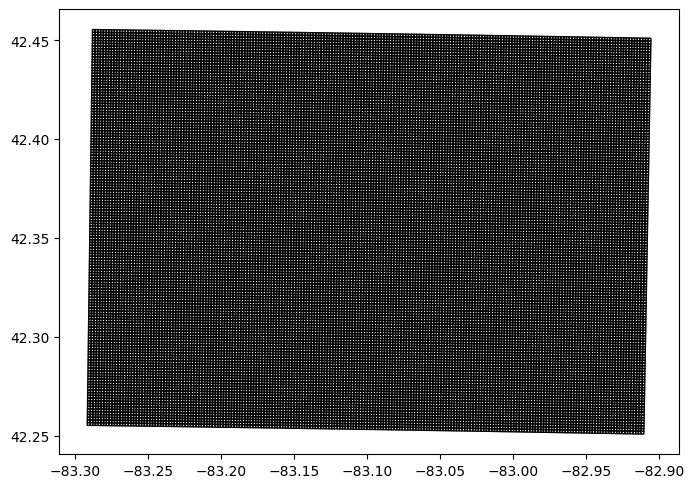

In [32]:
grid_153_4326.plot(figsize=(8, 8), edgecolor="black", facecolor="none") # plot the grid

In [33]:
# Summer 2018 NAIP imagery

search_2018 = catalog.search(
    collections=["naip"],
    bbox=bbox,
    datetime="2018-06-01/2018-09-30"
)

# Check its not zero

items_2018 = list(search_2018.item_collection())
print(f"2018 items: {len(items_2018)}")

2018 items: 25


In [34]:
# Summer 2022 NAIP imagery

search_2022 = catalog.search(
    collections=["naip"],
    bbox=bbox,
    datetime="2022-06-01/2022-09-30"
)

# Check its not zero

items_2022 = list(search_2022.item_collection())
print(f"2022 items: {len(items_2022)}")

2022 items: 25


In [35]:
# Get the URL and geometry for each tile

rows_2018 = []
for item in items_2018:
    rows_2018.append({
        "geometry": shape(item.geometry),   # <-- convert dict → shapely
        "url": item.assets["image"].href
    })

naip_grid_2018 = gpd.GeoDataFrame(rows_2018, geometry="geometry", crs="EPSG:4326")

rows_2022 = []
for item in items_2022:
    rows_2022.append({
        "geometry": shape(item.geometry),   # <-- convert dict → shapely
        "url": item.assets["image"].href
    })     
naip_grid_2022 = gpd.GeoDataFrame(rows_2022, geometry="geometry", crs="EPSG:4326")

<Axes: >

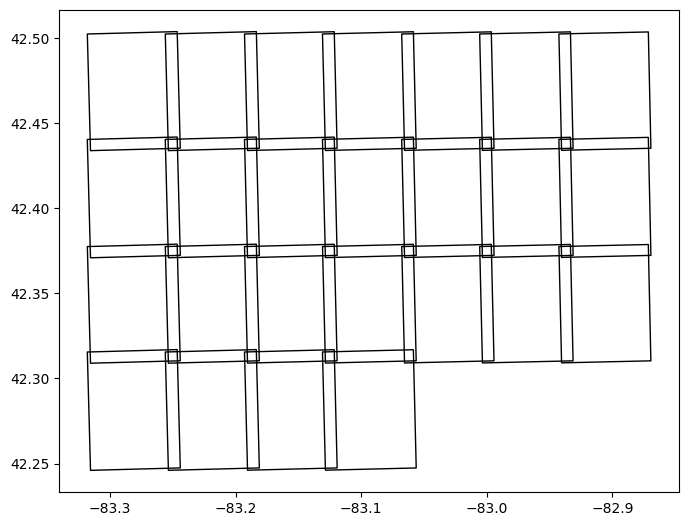

In [36]:
naip_grid_2018.plot(figsize=(8, 8), edgecolor="black", facecolor="none")

<Axes: >

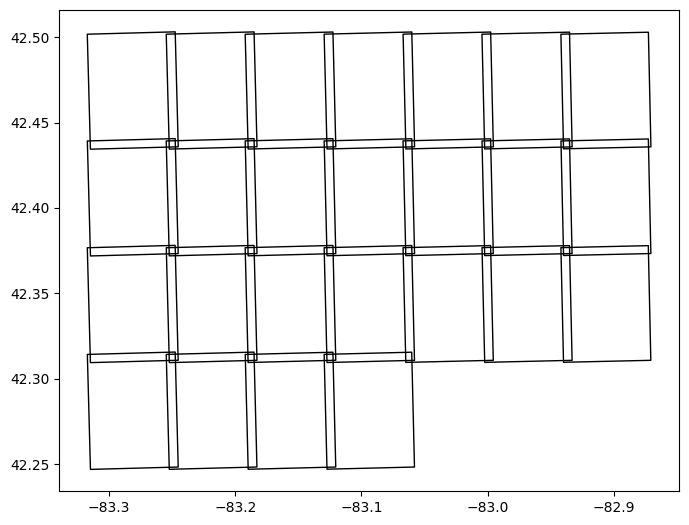

In [37]:
naip_grid_2022.plot(figsize=(8, 8), edgecolor="black", facecolor="none")

In [ ]:
# Join the grid with NAIP tiles so they are spatially joined and the urls are also attached to the grid cells 

joined_grid_2018 = gpd.sjoin(grid_153_4326, naip_grid_2018, how="left", predicate="intersects")

joined_grid_2022 = gpd.sjoin(grid_153_4326, naip_grid_2022, how="left", predicate="intersects")

In [38]:
# Check the results through the dataframe columns, should see url

print(joined_grid_2018.head())

print(joined_grid_2022.head())

                                            geometry  index_right  \
0  POLYGON ((-83.28574 42.24831, -83.28579 42.249...          2.0   
1  POLYGON ((-83.28579 42.2497, -83.28584 42.2510...          2.0   
2  POLYGON ((-83.28584 42.25108, -83.28589 42.252...          2.0   
3  POLYGON ((-83.28589 42.25246, -83.28594 42.253...          2.0   
4  POLYGON ((-83.28594 42.25384, -83.28599 42.255...          2.0   

                                                 url  
0  https://naipeuwest.blob.core.windows.net/naip/...  
1  https://naipeuwest.blob.core.windows.net/naip/...  
2  https://naipeuwest.blob.core.windows.net/naip/...  
3  https://naipeuwest.blob.core.windows.net/naip/...  
4  https://naipeuwest.blob.core.windows.net/naip/...  
                                            geometry  index_right  \
0  POLYGON ((-83.28574 42.24831, -83.28579 42.249...         21.0   
1  POLYGON ((-83.28579 42.2497, -83.28584 42.2510...         21.0   
2  POLYGON ((-83.28584 42.25108, -83.28589 42.25

Detroit Open Data Portal:
- DLBA Vacant Land Program Sales; between 2014 and 2025; separates between Neighborhood and Side Lots
- Completed Commercial Demolitions since 2014
- Completed Residential Demolitions since 2014 to 2026
- Parcels (current) last updated in 2024 but year built goes up to 2017 
- (Not Available for 2018-2023) Tenative Assessment Roll; Property Description and Use Code Description describe vacancy status and whether it's residential or commercial 

Urban Structure Changes in Three Areas of Detroit, Michigan (2014–2018) Utilizing Geographic Object-Based Classification
https://www.mdpi.com/2073-445X/12/4/763
- Calculates NDVI and % of impervious surfaces per parcel to as a secondary check 
- Maybe zonal statistics for certain ground truth data (like NDVI) to the clay chips? 
- Reverse aggregation for what majority vote of Clay and Alpha outputs say the parcels are 